In [2]:
#Research Question 1
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import ipympl
import matplotlib.pyplot as plt
%matplotlib ipympl
import seaborn as sns
import json
from pathlib import Path
import ncaa_bbStats as nb
import ncaa_bbStats.player_utils as pu
import os
import re
from scipy import stats

In [3]:
# Assuming it's a CSV; change to pd.read_json if it's a JSON file
mapping_path = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/team_names_stats/all_div_teams_standardized.csv")
team_map = pd.read_csv(mapping_path)

# Ensure the column names are clean
team_map.columns = team_map.columns.str.strip().str.lower()
# Standardize the names in the map for initial matching
team_map['match_key'] = team_map['team_name'].str.lower().str.strip()

display(team_map.head())

,team_id,team_name,division,match_key
0,1,A&M-Corpus Christi,1,a&m-corpus christi
1,2,AUM,2,aum
2,3,Abilene Christian University,1,abilene christian university
3,4,Abilene Christian,2,abilene christian
4,5,Academy of Art,2,academy of art


In [4]:
MY_DATA_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/player_stats_cache")
master_csv_path = MY_DATA_PATH / "batting" / "batting_noMin.csv"

# Define column names
required_stats = [
    'g', 'ab', 'pa', 'h', '1b', '2b', '3b', 'hr', 'r', 'rbi', 
    'bb', 'so', 'hbp', 'sf', 'sh', 'gdp', 'sb', 'cs', 'avg', 
    'bb%', 'k%', 'bb/k', 'obp', 'slg', 'ops', 'iso', 'spd', 
    'babip', 'wsb', 'wrc', 'wraa', 'woba', 'wrc+'
]

# Define id columns
id_columns = ['year', 'name', 'team', 'team name'] 

try:
    # 1. Load data
    full_stats_df = pd.read_csv(master_csv_path, usecols=id_columns + required_stats)
    
    # 2. Filter for 2010-2025
    master_roster_df = full_stats_df[
        (full_stats_df['year'] >= 2010) & (full_stats_df['year'] <= 2025)
    ].copy()
    
    # 3. Clean strings
    master_roster_df['team name'] = master_roster_df['team name'].astype(str).str.strip()
    master_roster_df['name'] = master_roster_df['name'].astype(str).str.strip()

    # --- NEW: ATTACH STANDARDIZED ID AND DIVISION ---
    # Create the same match_key you used in the team_map
    master_roster_df['match_key'] = master_roster_df['team name'].str.lower().apply(
        lambda x: re.sub(r'[^\w\s]', '', x)
    )
    
    # Merge with team_map to pull in 'id' and 'division'
    # We only take the columns we need from team_map to keep it clean
    master_roster_df = pd.merge(
        master_roster_df, 
        team_map[['match_key', 'team_id', 'division']], 
        on='match_key', 
        how='left'
    )
    # ------------------------------------------------
    
    # 4. Sort by ID, player, season
    # Using 'id' here instead of 'team name' ensures consistency
    master_roster_df = master_roster_df.sort_values(['team_id', 'name', 'year'])
    
    print(f"Successfully imported and tagged {len(master_roster_df)} records.")
    print(master_roster_df[['year', 'name', 'team name', 'team_id', 'division']].head())

except FileNotFoundError:
    print(f"Error: Could not find the file at {master_csv_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(master_roster_df.columns)

Successfully imported and tagged 26826 records.
       year            name                     team name  team_id  division
10004  2022  Aaron Staehely  Abilene Christian University      3.0       1.0
20637  2024  Aaron Staehely  Abilene Christian University      3.0       1.0
6396   2022       Adam Byrd  Abilene Christian University      3.0       1.0
1248   2021  Alexei Cazarin  Abilene Christian University      3.0       1.0
6529   2022  Alexei Cazarin  Abilene Christian University      3.0       1.0
Index(['name', 'team', 'team name', 'year', 'g', 'ab', 'pa', 'h', '1b', '2b',
       '3b', 'hr', 'r', 'rbi', 'bb', 'so', 'hbp', 'sf', 'sh', 'gdp', 'sb',
       'cs', 'avg', 'bb%', 'k%', 'bb/k', 'obp', 'slg', 'ops', 'iso', 'spd',
       'babip', 'wsb', 'wrc', 'wraa', 'woba', 'wrc+', 'match_key', 'team_id',
       'division'],
      dtype='object')


In [5]:
PITCH_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/player_stats_cache/pitching")
pitch_csv = PITCH_PATH / "pitching_noMin.csv"

# 2. Define ID columns (matching your batting script)
id_columns = ['year', 'name', 'team', 'team name'] 

# 3. Define the Pitching Stats columns
pitching_stats = [
    'age', 'playerid', 'w', 'l', 'era', 'g', 'gs', 'cg', 'sho', 'sv', 'ip', 'tbf',
    'h', 'r', 'er', 'hr', 'bb', 'hbp', 'wp', 'bk', 'so',
    'k/9', 'bb/9', 'k/bb', 'hr/9', 'k%', 'bb%', 'k-bb%', 
    'avg', 'whip', 'babip', 'lob%', 'fip', 'e-f'
]

try:
    # 4. Load data
    full_pitch_df = pd.read_csv(pitch_csv, usecols=id_columns + pitching_stats)
    
    # 5. Filter for 2010-2025
    master_pitching_df = full_pitch_df[
        (full_pitch_df['year'] >= 2010) & (full_pitch_df['year'] <= 2025)
    ].copy()
    
    # 6. Clean strings
    master_pitching_df['team name'] = master_pitching_df['team name'].astype(str).str.strip()
    master_pitching_df['name'] = master_pitching_df['name'].astype(str).str.strip()

    # --- NEW: ATTACH STANDARDIZED ID AND DIVISION ---
    # Apply the same logic used in the batting script
    master_pitching_df['match_key'] = master_pitching_df['team name'].str.lower().apply(
        lambda x: re.sub(r'[^\w\s]', '', x)
    )
    
    # Merge with team_map (Dimension Table) to pull in 'team_id' and 'division'
    master_pitching_df = pd.merge(
        master_pitching_df, 
        team_map[['match_key', 'team_id', 'division']], 
        on='match_key', 
        how='left'
    )
    # ------------------------------------------------

    # 7. Data Cleaning: Ensure numeric types for modeling
    master_pitching_df['ip'] = pd.to_numeric(master_pitching_df['ip'], errors='coerce')
    master_pitching_df['era'] = pd.to_numeric(master_pitching_df['era'], errors='coerce')
    
    # 8. Sort by team_id, player, season
    master_pitching_df = master_pitching_df.sort_values(['team_id', 'name', 'year'])
    
    print(f"Successfully imported and tagged {len(master_pitching_df)} pitching records.")
    print(master_pitching_df[['year', 'name', 'team name', 'team_id', 'division']].head())

except FileNotFoundError:
    print(f"Error: Could not find the file at {pitch_csv}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(master_pitching_df.columns)

Successfully imported and tagged 25964 pitching records.
       year             name                     team name  team_id  division
5997   2022        Adam Byrd  Abilene Christian University      3.0       1.0
10920  2023        Adam Byrd  Abilene Christian University      3.0       1.0
4354   2021  Adam Stephenson  Abilene Christian University      3.0       1.0
9424   2022  Adam Stephenson  Abilene Christian University      3.0       1.0
14483  2023  Adam Stephenson  Abilene Christian University      3.0       1.0
Index(['name', 'team', 'team name', 'age', 'playerid', 'year', 'w', 'l', 'era',
       'g', 'gs', 'cg', 'sho', 'sv', 'ip', 'tbf', 'h', 'r', 'er', 'hr', 'bb',
       'hbp', 'wp', 'bk', 'so', 'k/9', 'bb/9', 'k/bb', 'hr/9', 'k%', 'bb%',
       'k-bb%', 'avg', 'whip', 'babip', 'lob%', 'fip', 'e-f', 'match_key',
       'team_id', 'division'],
      dtype='object')


In [7]:
# PLAYER-LEVEL HITTING/PITCHING DATA
for df in [master_roster_df, master_pitching_df]:
    df['name'] = df['name'].str.strip()
    df['team_id'] = df['team_id'].astype(float)
    df['year'] = df['year'].astype(int)

# --- STEP 2: OUTER JOIN ON PLAYER-TEAM-YEAR ---
# This preserves hitters who don't pitch and pitchers who don't hit
master_player_df = pd.merge(
    master_roster_df, 
    master_pitching_df, 
    on=['name', 'team_id', 'year'], 
    how='outer', 
    suffixes=('_bat', '_pit')
)

# --- STEP 3: CLEAN UP SHARED COLUMNS ---
name_cols = ['team name', 'division', 'conference', 'team', 'match_key'] # Added match_key here
for col in name_cols:
    bat_col = f'{col}_bat'
    pit_col = f'{col}_pit'
    if bat_col in master_player_df.columns and pit_col in master_player_df.columns:
        master_player_df[col] = master_player_df[bat_col].fillna(master_player_df[pit_col])
        master_player_df = master_player_df.drop(columns=[bat_col, pit_col])
                                                 
print(f"Master Player Table Created: {len(master_player_df)} player-seasons.")
display(master_player_df[['name', 'team name', 'year', 'pa', 'ip']].head())

Master Player Table Created: 50891 player-seasons.


,name,team name,year,pa,ip
0,A.J. Arnold,Bellarmine University,2021,31.0,NaN
1,A.J. Arnold,Bellarmine University,2022,52.0,NaN
2,A.J. Causey,Jacksonville State University,2022,31.0,48.1
3,A.J. Causey,Jacksonville State University,2023,32.0,76.1
4,A.J. Causey,University of Tennessee Knoxville,2024,NaN,91.1


In [13]:
# LABEL PLAYER AS NEWCOMER, TRANSFER, OR RETURNER
roster_history = master_player_df[['name', 'team name', 'year', 'division', 'pa', 'ip']].copy()

# --- STEP 2: IDENTIFY RETURNING PLAYERS ---
# We create the "bridge" by shifting the year forward
history_check = roster_history.copy()
history_check['year'] = history_check['year'] + 1
history_check['stayed_put'] = True  # This column only exists in history_check for now

# Merge history_check into master_player_df
# This is what actually ADDS the 'stayed_put' column to your main table
master_player_df = pd.merge(
    master_player_df, 
    history_check[['name', 'team name', 'year', 'stayed_put']], 
    on=['name', 'team name', 'year'], 
    how='left'
)

# --- STEP 3: CREATE BOOLEAN FLAGS ---
# Now that the merge is done, 'stayed_put' exists in master_player_df
master_player_df['is_returner'] = master_player_df['stayed_put'].fillna(False)
master_player_df['is_newcomer'] = ~master_player_df['is_returner']

# --- STEP 4: IDENTIFY TRANSFERS ---
league_history = roster_history.copy()
league_history['year'] = league_history['year'] + 1
league_history = league_history.rename(columns={'team name': 'prev_team', 'division': 'prev_div'})

master_player_df = pd.merge(
    master_player_df,
    league_history[['name', 'year', 'prev_team', 'prev_div']],
    on=['name', 'year'],
    how='left'
)

# A transfer is a newcomer who was somewhere else last year
master_player_df['is_transfer'] = (master_player_df['is_newcomer']) & (master_player_df['prev_team'].notna())

print(f"Identification Complete.")
print(f"Returners: {master_player_df['is_returner'].sum()}")
print(f"Transfers: {master_player_df['is_transfer'].sum()}")

Identification Complete.
Returners: 21123
Transfers: 3765


/var/folders/rm/1w8z6ntd6gnfww6bknk77ybc0000gn/T/ipykernel_13484/88102973.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_player_df['is_returner'] = master_player_df['stayed_put'].fillna(False)


In [42]:
# --- STEP 1: DEFINE ADVANCED PILLARS ---
# These specific 7 metrics provided the 0.6843 signal
target_bat_cols = ['obp', 'iso', 'woba', 'wrc_plus']
target_pit_cols = ['fip', 'k_bb', 'k_9']
all_metrics = target_bat_cols + target_pit_cols

transfer_weights = {
    1.0: {'bat': 1.00, 'pit': 1.00},  # DI -> DI
    2.0: {'bat': 0.82, 'pit': 1.15},  # DII -> DI
    3.0: {'bat': 0.74, 'pit': 1.25},  # DIII -> DI
    'NJCAA': {'bat': 0.78, 'pit': 1.20} 
}

# --- STEP 2: APPLY ASYMMETRIC WEIGHTS ---
def weigh_advanced_stats(df):
    weighted_df = df.copy()
    for index, row in weighted_df.iterrows():
        if row['is_transfer']:
            weights = transfer_weights.get(row['prev_div'], transfer_weights['NJCAA'])
            
            # Weigh Hitting (Direct multiplication)
            for col in target_bat_cols:
                if col in weighted_df.columns:
                    weighted_df.at[index, col] = row[col] * weights['bat']
            
            # Weigh Pitching (Inversion for FIP)
            for col in target_pit_cols:
                if col in weighted_df.columns:
                    if 'fip' in col.lower():
                        # Increase the value (make worse) for transfers moving up
                        weighted_df.at[index, col] = row[col] * (2 - weights['pit'])
                    else:
                        weighted_df.at[index, col] = row[col] * weights['pit']
    return weighted_df

master_player_weighted = weigh_advanced_stats(master_player_df)

In [20]:
TEAM_CACHE_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/team_stats_cache")

all_record_data = []

# 2. Aggressive Normalizer (to ensure match_key consistency)
def aggressive_normalize(name):
    if not isinstance(name, str): return ""
    name = name.lower()
    name = re.sub(r'\(.*?\)', '', name) # Remove league abbreviations in parentheses
    name = re.sub(r'[^a-z0-9]', '', name) # Remove all non-alphanumeric characters
    if name.endswith('st'):
        name = name[:-2] + 'state'
    return name.strip()

# 3. Load the JSON Standings (2010-2025)
for div in [1, 2, 3]:
    div_folder = TEAM_CACHE_PATH / f"div{div}"
    for year in range(2010, 2026):
        file_path = div_folder / f"{year}.json"
        
        if file_path.exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
                
                # Filter out metadata keys like 'division' to keep only team dictionaries
                team_only_data = {k: v for k, v in data.items() if isinstance(v, dict)}
                
                # Create DataFrame
                df_year = pd.DataFrame.from_dict(team_only_data, orient='index')
                
                # Extract clean team name from the internal 'team' attribute
                if 'team' in df_year.columns:
                    df_year['team name'] = df_year['team']
                else:
                    # Fallback: Split the key at the first parenthesis
                    df_year['team name'] = df_year.index.str.split(' \(').str[0]
                
                # Keep only desired columns (W, L, T)
                # Note: Using .reindex ensures code doesn't crash if 'T' is missing in some files
                df_year = df_year.reindex(columns=['team name', 'W', 'L', 'T'])
                
                # Add Metadata
                df_year['year'] = year
                
                # Ensure numeric types
                for col in ['W', 'L', 'T']:
                    df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0)
                
                # Create W_Pct variable
                # Formula: Wins / Total Games
                df_year['W_Pct'] = df_year['W'] / (df_year['W'] + df_year['L'] + df_year['T'])
                # Handle division by zero
                df_year['W_Pct'] = df_year['W_Pct'].fillna(0)
                
                # Prevent duplicate columns before appending
                df_year = df_year.loc[:, ~df_year.columns.duplicated()]
                
                all_record_data.append(df_year)

# 4. Combine into Master Records DataFrame
master_records_df = pd.concat(all_record_data, ignore_index=True)

# 5. Attach Standardized team_id and division
# Ensure mapping match_key is consistent
team_map['match_key'] = team_map['team_name'].apply(aggressive_normalize)
master_records_df['match_key'] = master_records_df['team name'].apply(aggressive_normalize)

master_records_df = pd.merge(
    master_records_df, 
    team_map[['match_key', 'team_id', 'division']], 
    on='match_key', 
    how='left'
)

# 6. Final Clean and Sort
master_records_df = master_records_df.dropna(subset=['team_id'])
master_records_df = master_records_df.sort_values(['team_id', 'year'])

print(f"Import complete! Created 'master_records_df' with {len(master_records_df)} records.")
display(master_records_df[['year', 'team name', 'team_id', 'division', 'W', 'L', 'T', 'W_Pct']].head())


Import complete! Created 'master_records_df' with 11225 records.


,year,team name,team_id,division,W,L,T,W_Pct
171,2010,A&M-Corpus Christi,1.0,1.0,20,33,1,0.370370
363,2011,A&M-Corpus Christi,1.0,1.0,37,24,0,0.606557
808,2012,A&M-Corpus Christi,1.0,1.0,24,33,0,0.421053
984,2013,A&M-Corpus Christi,1.0,1.0,33,24,0,0.578947
1329,2014,A&M-Corpus Christi,1.0,1.0,31,27,0,0.534483


In [43]:
# --- STEP 3: AGGREGATE TO TEAM LEVEL ---
agg_dict = {col: 'mean' for col in all_metrics if col in master_player_weighted.columns}
agg_dict.update({'team name': 'first'})

team_talent_base = master_player_weighted.groupby(['team_id', 'year']).agg(agg_dict).reset_index()

# --- STEP 4: CALCULATE TEAM Z-SCORES ---
def standardize_advanced(df, metrics):
    final_df = df.copy()
    z_cols = []
    for col in metrics:
        if col in final_df.columns:
            z_col = f"{col}_z"
            z_cols.append(z_col)
            # Standardize relative to other teams in the SAME year
            final_df[z_col] = final_df.groupby('year')[col].transform(
                lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
            )
            # Invert FIP (since lower FIP is higher talent)
            if 'fip' in col.lower():
                final_df[z_col] = final_df[z_col] * -1
    return final_df, z_cols

team_rankings_adv, all_z_cols = standardize_advanced(team_talent_base, all_metrics)

# Create the Final Composite Total Talent Index
team_rankings_adv['total_talent_index'] = team_rankings_adv[all_z_cols].mean(axis=1)

In [47]:
# 1. DEFINE CONTINUITY LOGIC
def calculate_returning_stats(df, val_col):
    """Tracks workload returning to the same team_id the following year."""
    # Create a snapshot of player performance
    players = df[['name', 'team_id', 'year', val_col]].copy().fillna(0)
    
    # Create the 'bridge': A player's performance in Year N is 'returning' value for Year N+1
    prev_year = players.copy()
    prev_year['year'] = prev_year['year'] + 1
    prev_year = prev_year.rename(columns={val_col: 'returning_val'})
    
    # Inner merge tracks players who stayed with the same team_id
    merged = pd.merge(players, prev_year, on=['name', 'team_id', 'year'], how='inner')
    return merged.groupby(['team_id', 'year'])['returning_val'].sum().reset_index()

# 2. GENERATE COMPONENT TABLES
ret_bat = calculate_returning_stats(master_player_df, 'pa').rename(columns={'returning_val': 'ret_pa'})
ret_pit = calculate_returning_stats(master_player_df, 'ip').rename(columns={'returning_val': 'ret_ip'})

# 3. GET TEAM TOTALS (The Denominator)
# We shift team totals forward to align with the 'returning' year
team_totals = master_player_df.groupby(['team_id', 'year'])[['pa', 'ip']].sum().reset_index()
team_totals['year'] = team_totals['year'] + 1 
team_totals = team_totals.rename(columns={'pa': 'total_pa_last', 'ip': 'total_ip_last'})

# 4. FINAL CONTINUITY MERGE
continuity_df = pd.merge(ret_bat, ret_pit, on=['team_id', 'year'], how='outer')
continuity_df = pd.merge(continuity_df, team_totals, on=['team_id', 'year'], how='left')

# Calculate Percentages
continuity_df['batting_continuity'] = continuity_df['ret_pa'] / continuity_df['total_pa_last']
continuity_df['pitching_continuity'] = continuity_df['ret_ip'] / continuity_df['total_ip_last']

# Fill NAs for teams with no returning workload
continuity_df[['batting_continuity', 'pitching_continuity']] = continuity_df[['batting_continuity', 'pitching_continuity']].fillna(0)

# Pull team name back in for readability
continuity_df = pd.merge(continuity_df, team_map[['team_id', 'team_name']], on='team_id', how='left')

print(f"Continuity Model generated: {len(continuity_df)} team-seasons.")
display(continuity_df[['year', 'team_name', 'batting_continuity', 'pitching_continuity']].head())

Continuity Model generated: 1043 team-seasons.


,year,team_name,batting_continuity,pitching_continuity
0,2022,NaN,0.000000,0.000000
1,2023,NaN,0.000000,0.000000
2,2024,NaN,0.000000,0.000000
3,2025,NaN,0.000000,0.000000
4,2022,Abilene Christian University,0.768352,0.819891


In [48]:
# --- WIN% CHANGE MODEL ---

# 1. PREPARE THE DATA
# Sort by team_id and year to ensure the .diff() calculates the correct sequence
win_change_df = master_records_df.sort_values(['team_id', 'year']).copy()

# 2. CALCULATE YEAR-OVER-YEAR CHANGE
# .diff() calculates: (Current Year W_Pct) - (Previous Year W_Pct)
win_change_df['win_pct_change'] = win_change_df.groupby('team_id')['W_Pct'].diff()

# 3. CLEANUP
# We drop the first year for every team because a "change" cannot be calculated for Year 1
win_change_df = win_change_df.dropna(subset=['win_pct_change'])

print(f"Win % Change Model generated: {len(win_change_df)} team-seasons.")
display(win_change_df[['year', 'team name', 'team_id', 'W_Pct', 'win_pct_change']].head())

Win % Change Model generated: 10480 team-seasons.


,year,team name,team_id,W_Pct,win_pct_change
363,2011,A&M-Corpus Christi,1.0,0.606557,0.236187
808,2012,A&M-Corpus Christi,1.0,0.421053,-0.185505
984,2013,A&M-Corpus Christi,1.0,0.578947,0.157895
1329,2014,A&M-Corpus Christi,1.0,0.534483,-0.044465
1647,2015,A&M-Corpus Christi,1.0,0.490566,-0.043917


In [61]:
# --- STEP 5: FINAL MERGE (FIXED FOR MISSING INDICES) ---

# 1. SAFETY STEP: Ensure Unit Indices exist in team_rankings_adv
# This recreates the batting/pitching split based on your 7 pillars
bat_z = [c for c in all_z_cols if any(x in c for x in ['obp', 'iso', 'woba', 'wrc'])]
pit_z = [c for c in all_z_cols if any(x in c for x in ['fip', 'k_bb', 'k_9'])]

team_rankings_adv['batting_strength_index'] = team_rankings_adv[bat_z].mean(axis=1)
team_rankings_adv['pitching_strength_index'] = team_rankings_adv[pit_z].mean(axis=1)

# 2. DEFINE COLUMNS TO PULL
cols_to_pull = ['team_id', 'year', 'total_talent_index', 
                'batting_strength_index', 'pitching_strength_index']

# 3. PERFORM THE MERGE
final_research_table = pd.merge(
    win_change_df, 
    team_rankings_adv[cols_to_pull], 
    on=['team_id', 'year'], 
    how='left'
).sort_values(['team_id', 'year'])

# 4. CALCULATE TALENT GAIN
final_research_table['talent_improvement'] = final_research_table.groupby('team_id')['total_talent_index'].diff()

# --- STEP 6: CORRELATION RESULTS (NON-COVID) ---
clean_analysis = final_research_table[
    ~final_research_table['year'].isin([2020, 2021])
].dropna(subset=['total_talent_index', 'talent_improvement', 'win_pct_change']).copy()

talent_corr = clean_analysis['total_talent_index'].corr(clean_analysis['W_Pct'])
gain_corr = clean_analysis['talent_improvement'].corr(clean_analysis['win_pct_change'])

print(f"--- RESTORED ADVANCED MODEL RESULTS ---")
print(f"Overall Talent vs. Win % Correlation: {talent_corr:.4f}") 
print(f"Talent Gain vs. Win Improvement Correlation: {gain_corr:.4f}")

display(clean_analysis[['year', 'team name', 'batting_strength_index', 
                        'pitching_strength_index', 'total_talent_index']].tail(5))

--- RESTORED ADVANCED MODEL RESULTS ---
Overall Talent vs. Win % Correlation: 0.6335
Talent Gain vs. Win Improvement Correlation: 0.1705


,year,team name,batting_strength_index,pitching_strength_index,total_talent_index
7085,2025,Purdue Fort Wayne,-0.760799,-1.872393,-1.038698
9493,2022,Virginia Tech,1.881020,0.945267,1.647082
9494,2023,Virginia Tech,2.644818,0.730639,2.166274
9495,2024,Virginia Tech,1.540376,1.097703,1.429708
9496,2025,Virginia Tech,1.137328,1.334137,1.186530


In [51]:
# Run Pearson Correlation with P-Values
r_talent, p_talent = stats.pearsonr(clean_analysis['total_talent_index'], clean_analysis['W_Pct'])
r_gain, p_gain = stats.pearsonr(clean_analysis['talent_improvement'], clean_analysis['win_pct_change'])

print(f"--- STATISTICAL SIGNIFICANCE REPORT ---")
print(f"Talent vs. Win %: r = {r_talent:.4f}, p = {p_talent:.4e}")
print(f"Gain vs. Improvement: r = {r_gain:.4f}, p = {p_gain:.4f}")

if p_talent < 0.05:
    print("Conclusion: Total Talent Index is a highly significant predictor of Win %.")

--- STATISTICAL SIGNIFICANCE REPORT ---
Talent vs. Win %: r = 0.6335, p = 8.4256e-03
Gain vs. Improvement: r = 0.1705, p = 0.5279
Conclusion: Total Talent Index is a highly significant predictor of Win %.


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='total_talent_index', ylabel='W_Pct'>

Text(0.5, 1.0, 'The Talent-Win Relationship (2010-2025, Non-COVID)')

Text(0.5, 0, 'Total Talent Index (Weighted Z-Score)')

Text(0, 0.5, 'Winning Percentage')

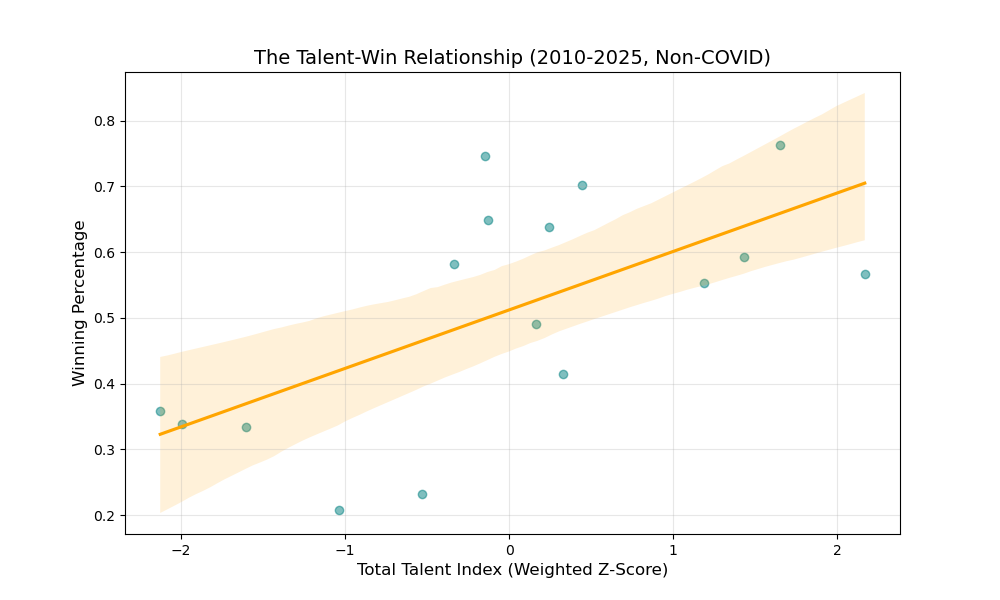

In [52]:
plt.figure(figsize=(10, 6))
sns.regplot(data=clean_analysis, x='total_talent_index', y='W_Pct', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'orange'})

plt.title('The Talent-Win Relationship (2010-2025, Non-COVID)', fontsize=14)
plt.xlabel('Total Talent Index (Weighted Z-Score)', fontsize=12)
plt.ylabel('Winning Percentage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='woba', ylabel='Density'>

<Axes: xlabel='woba', ylabel='Density'>

Text(0.5, 1.0, 'Visualizing the "Transfer Tax": Division Adjustments')

Text(0.5, 0, 'wOBA Value')

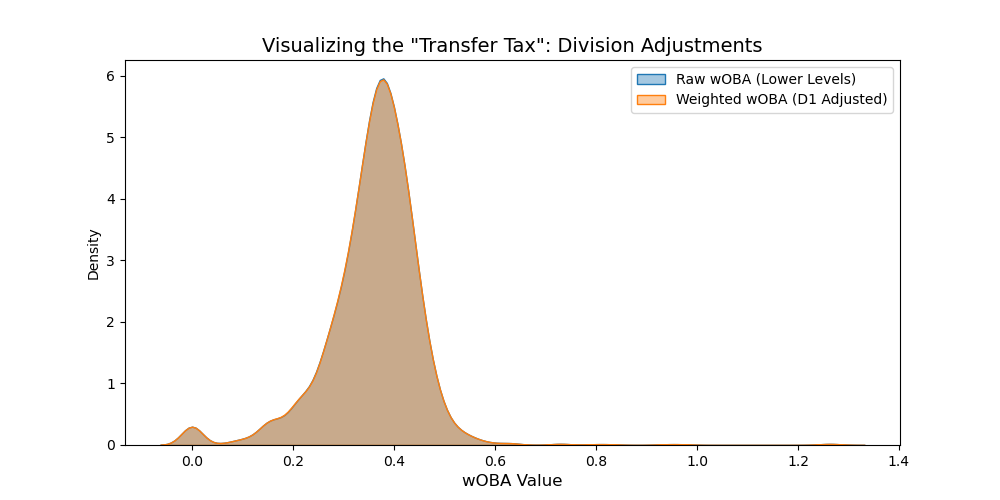

In [53]:
# Create a comparison of Raw vs Weighted wOBA for Transfers
transfers_only = master_player_df[master_player_df['is_transfer'] == True].copy()
transfers_weighted = master_player_weighted[master_player_weighted['is_transfer'] == True].copy()

plt.figure(figsize=(10, 5))
sns.kdeplot(transfers_only['woba'], label='Raw wOBA (Lower Levels)', fill=True, alpha=0.4)
sns.kdeplot(transfers_weighted['woba'], label='Weighted wOBA (D1 Adjusted)', fill=True, alpha=0.4)

plt.title('Visualizing the "Transfer Tax": Division Adjustments', fontsize=14)
plt.xlabel('wOBA Value', fontsize=12)
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='residual', ylabel='team name'>

Text(0.5, 1.0, 'Top 10 Season Overperformers (Wins Relative to Roster Talent)')

Text(0.5, 0, 'Win % Above Expectation')

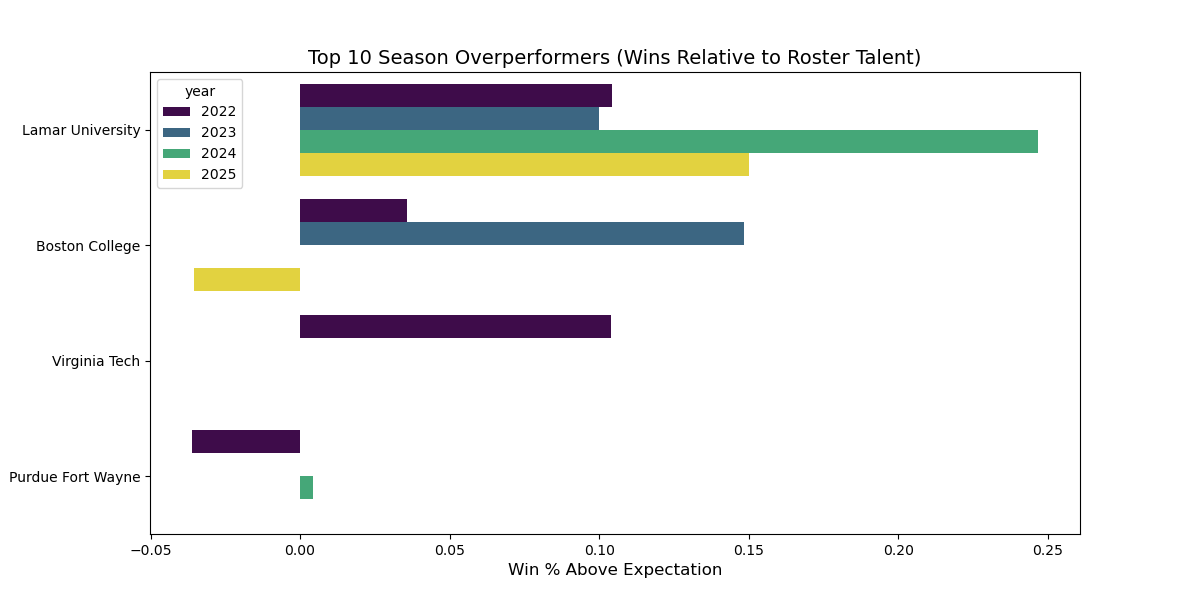

Retention metric successfully updated in clean_analysis.
National Average Roster Retention: 50.71%
Lamar Average Roster Retention: 45.55%


In [71]:
# Calculate Residuals (Win % minus Predicted Win % based on Talent)
from sklearn.linear_model import LinearRegression

X = clean_analysis[['total_talent_index']].values
y = clean_analysis['W_Pct'].values
model = LinearRegression().fit(X, y)
clean_analysis['predicted_w_pct'] = model.predict(X)
clean_analysis['residual'] = clean_analysis['W_Pct'] - clean_analysis['predicted_w_pct']

# Plot the 10 biggest overperformers of all time
overperformers = clean_analysis.sort_values('residual', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=overperformers, x='residual', y='team name', hue='year', palette='viridis')
plt.title('Top 10 Season Overperformers (Wins Relative to Roster Talent)', fontsize=14)
plt.xlabel('Win % Above Expectation', fontsize=12)
plt.show()

# --- STEP 1: FIX MISSING RETENTION METRIC (RE-RUNNABLE) ---

# 1. Calculate the percentage on the team-level performance dataframe
master_performance_df['roster_retention_pct'] = (
    master_performance_df['is_returner'] / 
    (master_performance_df['is_returner'] + master_performance_df['is_newcomer'])
).fillna(0)

# 2. CLEANUP: If we've run this before, drop the old column to avoid MergeError
if 'roster_retention_pct' in clean_analysis.columns:
    clean_analysis = clean_analysis.drop(columns=['roster_retention_pct'])

# 3. Merge the fresh metric into clean_analysis
clean_analysis = pd.merge(
    clean_analysis, 
    master_performance_df[['team_id', 'year', 'roster_retention_pct']], 
    on=['team_id', 'year'], 
    how='left'
)

print("Retention metric successfully updated in clean_analysis.")

# --- STEP 2: REFRESH LAMAR ANALYSIS ---

# Isolate Lamar and National Baseline
# Using .unique().iloc[0] is safer in case of multiple matches
lamar_match = clean_analysis[clean_analysis['team name'].str.contains('Lamar', case=False)]
if not lamar_match.empty:
    lamar_id = lamar_match['team_id'].unique()[0]
    lamar_years = clean_analysis[clean_analysis['team_id'] == lamar_id].copy()
    
    national_avg_retention = clean_analysis['roster_retention_pct'].mean()
    print(f"National Average Roster Retention: {national_avg_retention:.2%}")
    print(f"Lamar Average Roster Retention: {lamar_years['roster_retention_pct'].mean():.2%}")
else:
    print("Lamar not found in the dataset.")

<Figure size 1200x600 with 0 Axes>

<BarContainer object of 4 artists>

Text(2022, 0.4558974358974359, 'Residual: +0.10')

Text(2023, 0.5335135135135135, 'Residual: +0.10')

Text(2024, 0.5335135135135135, 'Residual: +0.25')

Text(2025, 0.378974358974359, 'Residual: +0.15')

Text(0.5, 1.0, 'Lamar Program Stability vs. National Average')

Text(0, 0.5, 'Roster Retention Rate (%)')

(0.0, 1.0)

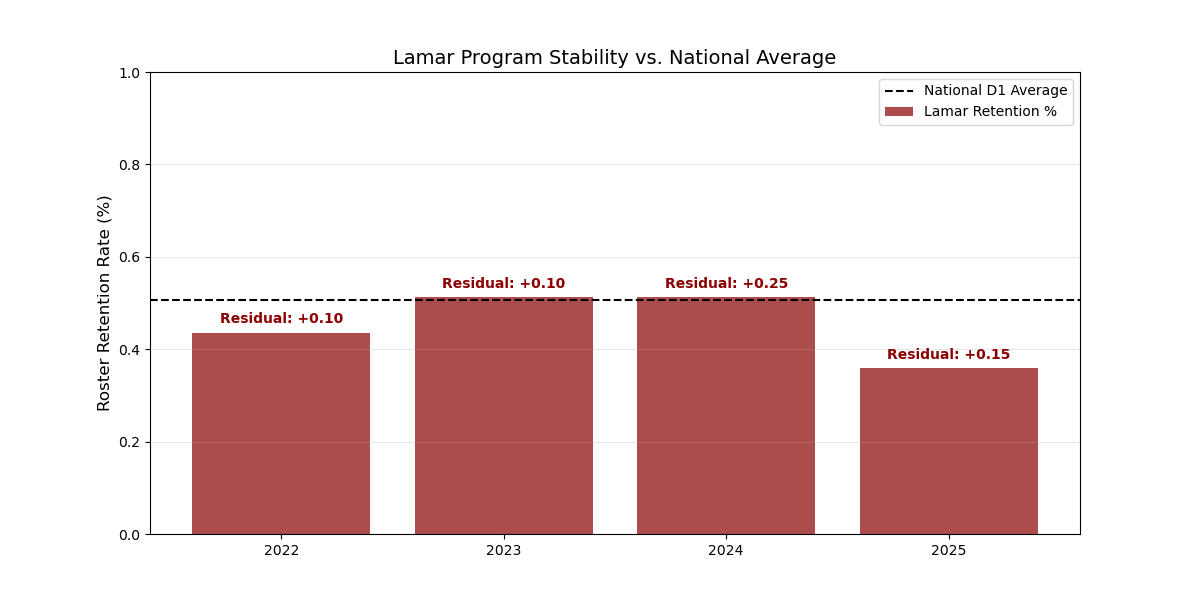

In [72]:
# --- STEP 2: VISUALIZE THE STABILITY GAP ---

plt.figure(figsize=(12, 6))
years_str = lamar_years['year'].astype(str)

plt.bar(years_str, lamar_years['roster_retention_pct'], color='darkred', alpha=0.7, label='Lamar Retention %')
plt.axhline(national_avg_retention, color='black', linestyle='--', label='National D1 Average')

# Annotate the Residual (The "Overperformance" amount)
for i, row in lamar_years.iterrows():
    plt.text(str(row['year']), row['roster_retention_pct'] + 0.02, 
             f"Residual: +{row['residual']:.2f}", ha='center', fontweight='bold', color='darkred')

plt.title('Lamar Program Stability vs. National Average', fontsize=14)
plt.ylabel('Roster Retention Rate (%)', fontsize=12)
plt.ylim(0, 1.0) # Scale 0 to 100%
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [73]:
# --- STEP 3: UNIT STRENGTH ANALYSIS ---

# Calculate the 'Dominance Tilt' (Which unit is driving the overperformance?)
lamar_years['pitching_tilt'] = lamar_years['pitching_strength_index'] - lamar_years['batting_strength_index']

print("--- LAMAR UNIT STRENGTH DURING OVERPERFORMANCE ---")
display(lamar_years[['year', 'residual', 'roster_retention_pct', 'batting_strength_index', 'pitching_strength_index', 'pitching_tilt']])

--- LAMAR UNIT STRENGTH DURING OVERPERFORMANCE ---


,year,residual,roster_retention_pct,batting_strength_index,pitching_strength_index,pitching_tilt
4,2022,0.104095,0.435897,0.306720,0.054707,-0.252013
5,2023,0.099831,0.513514,-0.790985,1.018387,1.809372
6,2024,0.246538,0.513514,-0.212061,0.056060,0.268121
7,2025,0.150023,0.358974,0.385324,0.622864,0.237540


In [2]:
#Research Question 2
#allow output from every line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib notebook
import seaborn as sns
import math

In [3]:
#Load all necessary files
twenty_10 = pd.read_json("2010.json")
twenty_11 = pd.read_json("2011.json")
twenty_12 = pd.read_json("2012.json")
twenty_13 = pd.read_json("2013.json")
twenty_14 = pd.read_json("2014.json")
twenty_15 = pd.read_json("2015.json")
twenty_16 = pd.read_json("2016.json")
twenty_17 = pd.read_json("2017.json")
twenty_18 = pd.read_json("2018.json")
twenty_19 = pd.read_json("2019.json")
twenty_20 = pd.read_json("2020.json")
twenty_21 = pd.read_json("2021.json")
twenty_22 = pd.read_json("2022.json")
twenty_23 = pd.read_json("2023.json")
twenty_24 = pd.read_json("2024.json")
twenty_25 = pd.read_json("2025.json")

#Batting Stats/Rosters
batting_nomin = pd.read_csv("batting_noMin.csv")
batting_qualified = pd.read_csv("batting_qualified.csv")
batting = pd.concat([batting_nomin, batting_qualified])
batting

#Pitching Stats/Rosters
pitching_nomin = pd.read_csv("pitching_noMin.csv")
pitching_qualified = pd.read_csv("pitching_qualified.csv")
pitching = pd.concat([pitching_nomin, pitching_qualified])
pitching

,name,team,team name,age,nameascii,playerid,mlbamid,year,g,ab,...,slg,ops,iso,spd,babip,wsb,wrc,wraa,woba,wrc+
0,Blake Dunn,WMU,Western Michigan University,22.0,Blake Dunn,29487,694362.0,2021,27,59,...,0.576271,1.050630,0.271186,5.438424,0.350000,0.056455,20.038378,8.258539,0.483122,170.107404
1,Ryan Bliss,AUB,Auburn University,21.0,Ryan Bliss,29547,669208.0,2021,50,211,...,0.654028,1.081995,0.289100,4.974168,0.371257,-1.456794,58.746606,20.674834,0.467360,154.304890
2,Adrian Del Castillo,MIA,University of Miami,21.0,Adrian Del Castillo,29554,680728.0,2021,54,200,...,0.395000,0.774747,0.120000,4.409581,0.304094,0.022838,35.612792,-0.514145,0.360145,98.576837
3,Tim Tawa,STAN,Stanford University,22.0,Tim Tawa,29571,694374.0,2021,52,214,...,0.518692,0.875834,0.228972,6.323953,0.304878,1.181782,41.118764,4.050893,0.390554,110.928313
4,Billy Cook,PEPP,Pepperdine University,22.0,Billy Cook,29573,695257.0,2021,33,131,...,0.725191,1.110812,0.427481,7.549825,0.301370,0.522476,36.614354,16.183401,0.474676,179.210213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11524,Anthony Mascuilli,UMBC,"University of Maryland, Baltimore County",NaN,Anthony Mascuilli,sa3066388,NaN,2025,39,132,...,0.401515,0.861742,0.098485,6.696172,0.345133,0.227533,36.666240,8.963793,0.427325,132.357406
11525,Paul Contreras,CSUF,"California State University, Fullerton",NaN,Paul Contreras,sa3066537,NaN,2025,38,143,...,0.468531,0.810146,0.209790,6.480733,0.310000,0.276773,23.388718,-1.370996,0.369565,94.462795
11526,Mac Floyd,MVSU,Mississippi Valley State University,NaN,Mac Floyd,sa3066616,NaN,2025,37,104,...,0.365385,0.726040,0.105769,6.458498,0.346667,-0.623230,15.503391,-7.153637,0.355985,68.426410
11527,Bryce Campbell,NMSU,New Mexico State University,21.0,Bryce Campbell,sa3066700,NaN,2025,39,153,...,0.477124,0.872729,0.183007,1.669496,0.339130,-0.237017,33.133894,2.618525,0.399093,108.581002


,name,team,team name,age,nameascii,playerid,mlbamid,year,w,l,...,hr/9,k%,bb%,k-bb%,avg,whip,babip,lob%,fip,e-f
0,Gordon Graceffo,VILL,Villanova University,21.0,Gordon Graceffo,29519,700669.0,2021,7,2,...,0.000000,0.264615,0.040000,0.224615,0.214984,0.963415,0.298643,0.714286,2.242553,-0.705967
1,Fraser Ellard,LIB,Liberty University,23.0,Fraser Ellard,29530,686642.0,2021,0,1,...,0.609023,0.333333,0.068783,0.264550,0.211765,1.105263,0.317308,0.669291,3.474132,0.180003
2,Andre Granillo,UCR,"University of California, Riverside",21.0,Andre Granillo,29542,701552.0,2021,2,0,...,0.000000,0.276596,0.085106,0.191489,0.205128,1.161290,0.307692,0.437500,3.844890,2.251884
3,Patrick Monteverde,TTU,Texas Tech University,23.0,Patrick Monteverde,29564,687287.0,2021,7,4,...,1.042471,0.281337,0.058496,0.222841,0.235821,1.158301,0.308036,0.674157,3.687751,0.065144
4,Chase Lee,ALA,University of Alabama,22.0,Chase Lee,29574,695445.0,2021,7,0,...,0.885246,0.305389,0.083832,0.221557,0.195946,1.057377,0.268817,0.943396,3.800601,-2.472732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25959,Caden Fredericks,GCU,Grand Canyon University,NaN,Caden Fredericks,sa3067296,NaN,2025,0,0,...,0.000000,0.166667,0.333333,-0.166667,0.333333,4.500000,0.500000,0.750000,14.924470,-1.424470
25960,Parker Massey,ARMY,United States Military Academy,NaN,Parker Massey,sa3067297,NaN,2025,0,0,...,0.000000,0.000000,0.000000,0.000000,0.500000,3.000000,0.500000,1.000000,4.695776,-4.695776
25961,Chase Nelson,STMN,St. Mary's University,NaN,Chase Nelson,sa3067298,NaN,2025,0,0,...,0.000000,0.000000,0.250000,-0.250000,0.333333,3.000000,0.333333,0.000000,9.256659,17.743340
25962,Cole Frye,FAU,Florida Atlantic University,21.0,Cole Frye,sa3067481,NaN,2025,0,0,...,0.000000,0.166667,0.166667,0.000000,0.400000,1.800000,0.500000,1.000000,4.563206,-4.563206


In [4]:
#create dataframe
dfs = [twenty_10, twenty_11, twenty_12, twenty_13, twenty_14, twenty_15, twenty_16, twenty_17, twenty_18, twenty_19,
      twenty_20, twenty_21, twenty_22, twenty_23, twenty_24, twenty_25]

seasons = ['2010','2011','2012','2013','2014','2015','2016','2016','2017','2018','2019','2020',
          '2021','2022','2023','2024','2025']
common_stats = set.intersection(*[set(df.index) for df in dfs])

#Transpose data to switch rows and columns
transposed = []
for df, season in zip(dfs,seasons):
    t = df.loc[list(common_stats)].transpose()
    t['Season'] = season
    transposed.append(t)

years = pd.concat(transposed)

#Dropped Division because it was in the rows with teams and not a column
years = years.drop(index = 'division')
years

,ER,PO,BA,HA,SB,R (Pitching),W,H,ERA,league,...,SF,3B,DP,team,L,G,BB (Batting),R (Batting),A,Season
Florida St. (ACC),292,1796,0.3,597,97,356,48,688,4.39,ACC,...,44,22,58,Florida St.,20,68,402,543,734,2010
New Mexico St. (WAC),426,1541,0.349,732,27,511,36,776,7.46,WAC,...,28,17,64,New Mexico St.,23,60,382,613,640,2010
Clemson (ACC),326,1878,0.306,684,106,385,45,764,4.69,ACC,...,42,15,81,Clemson,25,70,375,600,712,2010
NC State (ACC),326,1664,0.326,608,42,394,38,747,5.29,ACC,...,31,16,58,NC State,24,62,333,571,638,2010
Arizona St. (Pac-12),206,1674,0.337,508,136,248,52,734,3.32,Pac-12,...,24,37,61,Arizona St.,10,62,320,520,673,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),388,1210,0.241,532,25,445,10,384,8.66,MVC,...,9,7,30,Valparaiso,40,50,200,249,406,2024
Delaware St. (NEC),409,954,0.259,486,53,513,7,333,11.58,NEC,...,18,2,18,Delaware St.,34,41,158,187,306,2024
UMES (NEC),421,1161,0.262,540,48,494,7,410,9.78,NEC,...,21,7,32,UMES,41,48,195,255,436,2024
Alcorn (SWAC),557,1098,0.293,596,153,651,6,447,13.67,SWAC,...,22,15,22,Alcorn,43,49,197,298,376,2024


In [5]:
#Create W/L%
years['W/L%'] = years['W']/(years['W']+years['L'])
years

,ER,PO,BA,HA,SB,R (Pitching),W,H,ERA,league,...,3B,DP,team,L,G,BB (Batting),R (Batting),A,Season,W/L%
Florida St. (ACC),292,1796,0.3,597,97,356,48,688,4.39,ACC,...,22,58,Florida St.,20,68,402,543,734,2010,0.705882
New Mexico St. (WAC),426,1541,0.349,732,27,511,36,776,7.46,WAC,...,17,64,New Mexico St.,23,60,382,613,640,2010,0.610169
Clemson (ACC),326,1878,0.306,684,106,385,45,764,4.69,ACC,...,15,81,Clemson,25,70,375,600,712,2010,0.642857
NC State (ACC),326,1664,0.326,608,42,394,38,747,5.29,ACC,...,16,58,NC State,24,62,333,571,638,2010,0.612903
Arizona St. (Pac-12),206,1674,0.337,508,136,248,52,734,3.32,Pac-12,...,37,61,Arizona St.,10,62,320,520,673,2010,0.83871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),388,1210,0.241,532,25,445,10,384,8.66,MVC,...,7,30,Valparaiso,40,50,200,249,406,2024,0.2
Delaware St. (NEC),409,954,0.259,486,53,513,7,333,11.58,NEC,...,2,18,Delaware St.,34,41,158,187,306,2024,0.170732
UMES (NEC),421,1161,0.262,540,48,494,7,410,9.78,NEC,...,7,32,UMES,41,48,195,255,436,2024,0.145833
Alcorn (SWAC),557,1098,0.293,596,153,651,6,447,13.67,SWAC,...,15,22,Alcorn,43,49,197,298,376,2024,0.122449


In [6]:
#Seperate Power 5 from Mid-Major
Power5 = ('ACC','SEC','Big Ten','Big 12','Pac-12')
years['Power5']= years['league'].isin(Power5).astype(int)
years


,ER,PO,BA,HA,SB,R (Pitching),W,H,ERA,league,...,DP,team,L,G,BB (Batting),R (Batting),A,Season,W/L%,Power5
Florida St. (ACC),292,1796,0.3,597,97,356,48,688,4.39,ACC,...,58,Florida St.,20,68,402,543,734,2010,0.705882,1
New Mexico St. (WAC),426,1541,0.349,732,27,511,36,776,7.46,WAC,...,64,New Mexico St.,23,60,382,613,640,2010,0.610169,0
Clemson (ACC),326,1878,0.306,684,106,385,45,764,4.69,ACC,...,81,Clemson,25,70,375,600,712,2010,0.642857,1
NC State (ACC),326,1664,0.326,608,42,394,38,747,5.29,ACC,...,58,NC State,24,62,333,571,638,2010,0.612903,1
Arizona St. (Pac-12),206,1674,0.337,508,136,248,52,734,3.32,Pac-12,...,61,Arizona St.,10,62,320,520,673,2010,0.83871,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),388,1210,0.241,532,25,445,10,384,8.66,MVC,...,30,Valparaiso,40,50,200,249,406,2024,0.2,0
Delaware St. (NEC),409,954,0.259,486,53,513,7,333,11.58,NEC,...,18,Delaware St.,34,41,158,187,306,2024,0.170732,0
UMES (NEC),421,1161,0.262,540,48,494,7,410,9.78,NEC,...,32,UMES,41,48,195,255,436,2024,0.145833,0
Alcorn (SWAC),557,1098,0.293,596,153,651,6,447,13.67,SWAC,...,22,Alcorn,43,49,197,298,376,2024,0.122449,0


In [7]:
#Calculate standard deviation of win percentage
team_consistency = years.groupby('team')['W/L%'].std().reset_index()
team_consistency.columns = ['team','W/L%_std']
team_consistency

#Bring Power 5 label into team_consistency
labels = years[['team','Power5']].drop_duplicates()
team_consistency = team_consistency.merge(labels, on = 'team')
team_consistency

,team,W/L%_std
0,A&M-Corpus Christi,0.074150
1,Abilene Christian,0.080637
2,Air Force,0.100618
3,Akron,0.109170
4,Alabama,0.131918
...,...,...
310,Wofford,0.141535
311,Wright St.,0.097464
312,Xavier,0.089112
313,Yale,0.113875


,team,W/L%_std,Power5
0,A&M-Corpus Christi,0.074150,0
1,Abilene Christian,0.080637,0
2,Air Force,0.100618,0
3,Akron,0.109170,0
4,Alabama,0.131918,1
...,...,...,...
323,Wofford,0.141535,0
324,Wright St.,0.097464,0
325,Xavier,0.089112,0
326,Yale,0.113875,0


In [8]:
#Calculate total number of games per team
games_per_team = years.groupby('team')['G'].sum().reset_index()
games_per_team.columns = ('team','total_games')

games_per_team['ideal_std'] = 0.5/(games_per_team['total_games'].apply(math.sqrt))

combined = games_per_team.merge(team_consistency, on = 'team')
combined

,team,total_games,ideal_std,W/L%_std,Power5
0,A&M-Corpus Christi,848,0.017170,0.074150,0
1,Abilene Christian,411,0.024663,0.080637,0
2,Air Force,835,0.017303,0.100618,0
3,Akron,613,0.020195,0.109170,0
4,Alabama,906,0.016611,0.131918,1
...,...,...,...,...,...
323,Wofford,891,0.016751,0.141535,0
324,Wright St.,877,0.016884,0.097464,0
325,Xavier,886,0.016798,0.089112,0
326,Yale,606,0.020311,0.113875,0


In [9]:
#Sort batting by player and year
batting_sorted = batting.sort_values(['name', 'year'])

#See which players were on previous teams in years prior
batting_sorted['prev_team'] = batting_sorted.groupby('name')['team name'].shift(1)
batting_sorted['prev_year'] = batting_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the batting data
batting_sorted['is_transfer'] = (
    (batting_sorted['team name'] != batting_sorted['prev_team']) &
    (batting_sorted['year'] == batting_sorted['prev_year'] + 1) &
    (batting_sorted['prev_team'].notna())
)

transfers = batting_sorted[batting_sorted['is_transfer']]
print(f"Total batting transfers: {len(transfers)}")

#sort pitching data by player and year
pitching_sorted = pitching.sort_values(['name', 'year'])

#Find which pitchers were on other rosters in previous years
pitching_sorted['prev_team'] = pitching_sorted.groupby('name')['team name'].shift(1)
pitching_sorted['prev_year'] = pitching_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the pitching data
pitching_sorted['is_transfer'] = (
    (pitching_sorted['team name'] != pitching_sorted['prev_team']) &
    (pitching_sorted['year'] == pitching_sorted['prev_year'] + 1) &
    (pitching_sorted['prev_team'].notna())
)
#Print outcome
transfers_p = pitching_sorted[pitching_sorted['is_transfer']]
print(f"Total pitching transfers: {len(transfers_p)}")

Total batting transfers: 1746
Total pitching transfers: 1737


In [10]:
power5 = {'ACC', 'Big Ten', 'Big 12', 'SEC', 'Pac-12'}

total_transfers = pd.concat([transfers, transfers_p])

team_conference = years[['team', 'league']].drop_duplicates()
team_conference.columns = ['team name', 'league']

total_transfers = total_transfers.merge(team_conference, on='team name', how='left')

# Find number of transfers into Power 5 conferences
transfers_into_p5 = total_transfers[total_transfers['league'].isin(power5)]
#Find number of transfers into Mid-Major Conferences
transfers_to_nonp5 = total_transfers[~total_transfers['league'].isin(power5)]


#Print transfers into Power 5 and Mid-Major conferences by year
print(transfers_to_nonp5.groupby('year')['name'].count())
print(transfers_into_p5.groupby('year')['name'].count())


year
2022     693
2023     805
2024     916
2025    1060
Name: name, dtype: int64
year
2022     8
2023     7
2024    11
2025    14
Name: name, dtype: int64


<IPython.core.display.Javascript object>


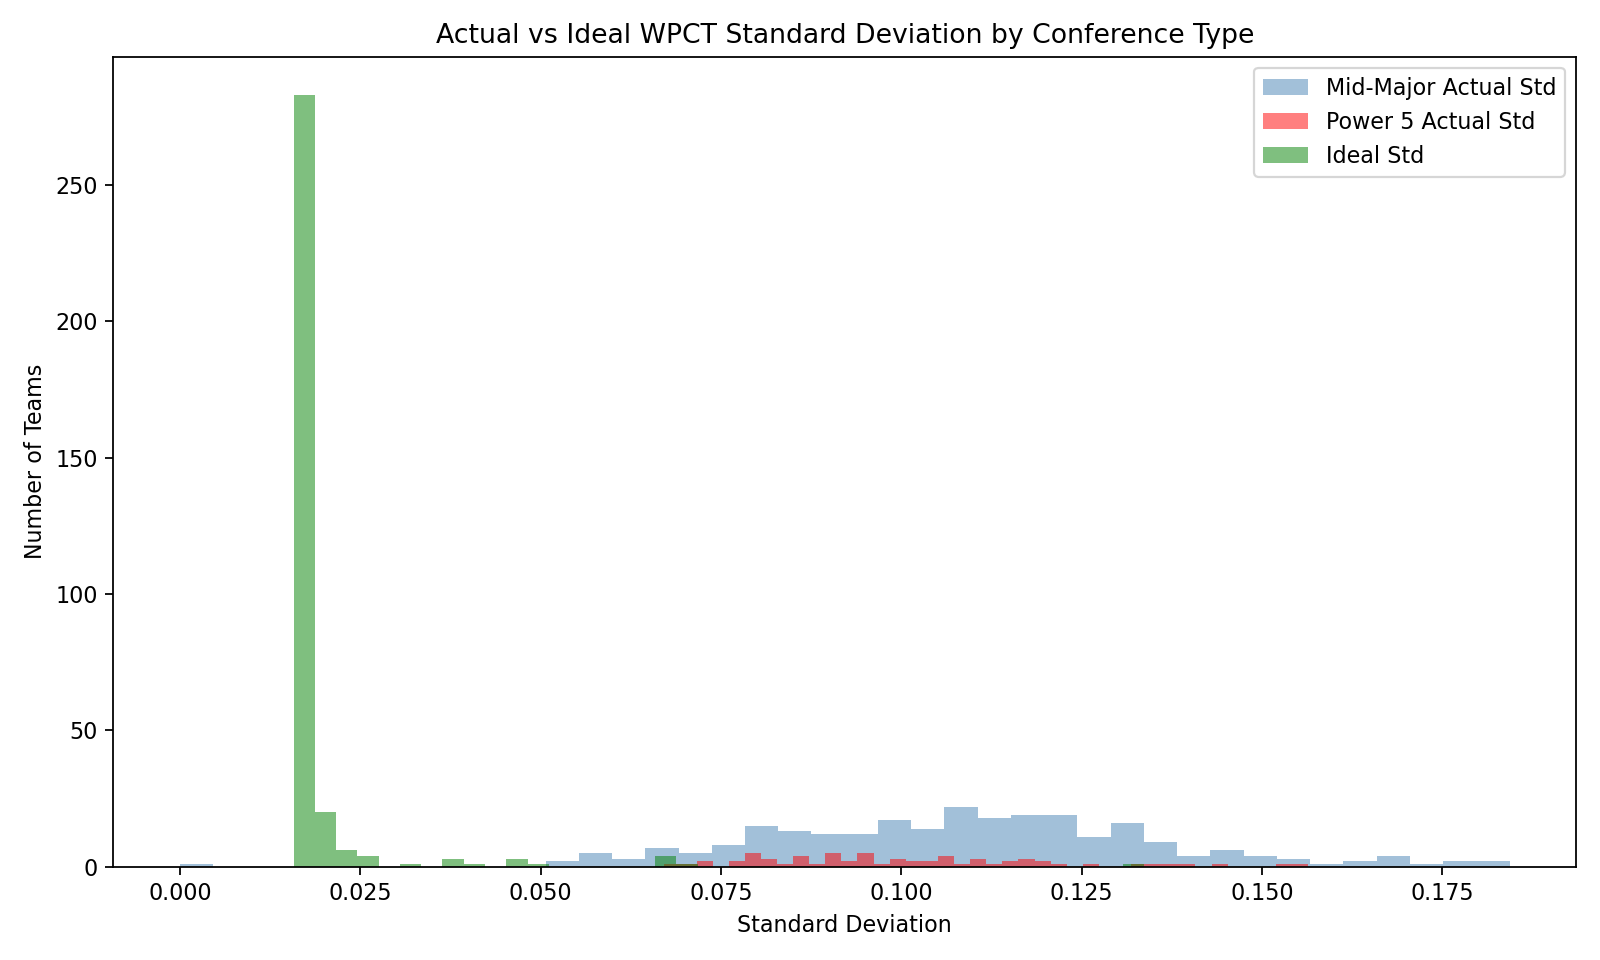

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  5.,
         3.,  7.,  5.,  8., 15., 13., 12., 12., 17., 14., 22., 18., 19.,
        19., 11., 16.,  9.,  4.,  6.,  4.,  3.,  1.,  2.,  4.,  1.,  2.,
         2.]),
 array([0.        , 0.0046079 , 0.00921579, 0.01382369, 0.01843159,
        0.02303948, 0.02764738, 0.03225528, 0.03686317, 0.04147107,
        0.04607897, 0.05068687, 0.05529476, 0.05990266, 0.06451056,
        0.06911845, 0.07372635, 0.07833425, 0.08294214, 0.08755004,
        0.09215794, 0.09676583, 0.10137373, 0.10598163, 0.11058952,
        0.11519742, 0.11980532, 0.12441322, 0.12902111, 0.13362901,
        0.13823691, 0.1428448 , 0.1474527 , 0.1520606 , 0.15666849,
        0.16127639, 0.16588429, 0.17049218, 0.17510008, 0.17970798,
        0.18431587]),
 <BarContainer object of 40 artists>)

(array([1., 1., 2., 0., 2., 5., 3., 1., 4., 1., 5., 2., 5., 1., 3., 2., 2.,
        4., 1., 3., 1., 2., 3., 2., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0.,
        1., 0., 0., 0., 1., 1.]),
 array([0.06715022, 0.06938143, 0.07161264, 0.07384385, 0.07607506,
        0.07830627, 0.08053748, 0.08276869, 0.0849999 , 0.08723111,
        0.08946232, 0.09169353, 0.09392474, 0.09615595, 0.09838716,
        0.10061837, 0.10284958, 0.10508079, 0.10731201, 0.10954322,
        0.11177443, 0.11400564, 0.11623685, 0.11846806, 0.12069927,
        0.12293048, 0.12516169, 0.1273929 , 0.12962411, 0.13185532,
        0.13408653, 0.13631774, 0.13854895, 0.14078016, 0.14301137,
        0.14524258, 0.14747379, 0.149705  , 0.15193621, 0.15416742,
        0.15639863]),
 <BarContainer object of 40 artists>)

(array([283.,  20.,   6.,   4.,   0.,   1.,   0.,   3.,   1.,   0.,   3.,
          1.,   0.,   0.,   0.,   0.,   0.,   4.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([0.01577201, 0.01871847, 0.02166494, 0.0246114 , 0.02755787,
        0.03050433, 0.0334508 , 0.03639726, 0.03934373, 0.0422902 ,
        0.04523666, 0.04818313, 0.05112959, 0.05407606, 0.05702252,
        0.05996899, 0.06291545, 0.06586192, 0.06880838, 0.07175485,
        0.07470131, 0.07764778, 0.08059424, 0.08354071, 0.08648718,
        0.08943364, 0.09238011, 0.09532657, 0.09827304, 0.1012195 ,
        0.10416597, 0.10711243, 0.1100589 , 0.11300536, 0.11595183,
        0.11889829, 0.12184476, 0.12479122, 0.12773769, 0.13068416,
        0.13363062]),
 <BarContainer object of 40 artists>)

Text(0.5, 1.0, 'Actual vs Ideal WPCT Standard Deviation by Conference Type')

Text(0.5, 0, 'Standard Deviation')

Text(0, 0.5, 'Number of Teams')

In [11]:
#Create overlapped histogram to show ideal std vs actual std with Power 5 conferences highlighted
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = combined[combined['Power5'] == False]['W/L%_std']
power5 = combined[combined['Power5'] == True]['W/L%_std']
ideal = combined['ideal_std']

ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Actual Std')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Actual Std')
ax.hist(ideal, bins=40, alpha=0.5, color='green', label='Ideal Std')

ax.set_title("Actual vs Ideal WPCT Standard Deviation by Conference Type")
ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("idealvsactual.pdf")


<IPython.core.display.Javascript object>


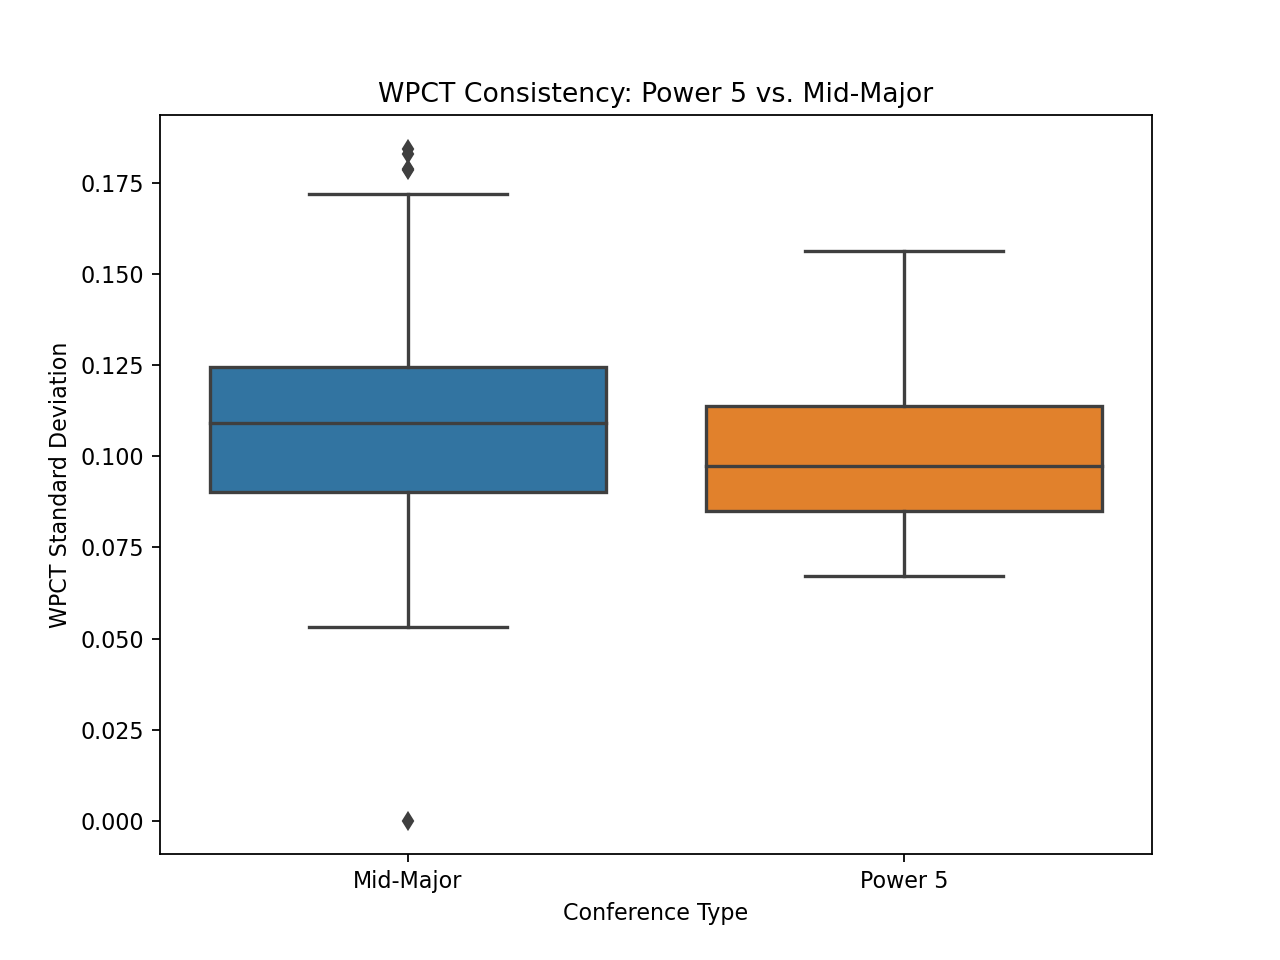

<Axes: xlabel='Conference Type', ylabel='W/L%_std'>

Text(0.5, 1.0, 'WPCT Consistency: Power 5 vs. Mid-Major')

Text(0, 0.5, 'WPCT Standard Deviation')

In [12]:
#Create side-by-side box plot to show the variance of win percentage
import seaborn as sns

team_consistency['Conference Type'] = team_consistency['Power5'].astype(int).map({1:'Power 5', 0:'Mid-Major'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=team_consistency, x='Conference Type', y='W/L%_std', ax=ax)
ax.set_title('WPCT Consistency: Power 5 vs. Mid-Major')
ax.set_ylabel('WPCT Standard Deviation')

fig.savefig("win_consistency.pdf")

In [13]:
#Calculate Roster Continuity - batting and pitching seperate

batting['returning'] = batting.groupby('name')['year'].diff() == 1

batting_continuity = batting.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'pa'].sum() / x['pa'].sum()
).reset_index(name='batting_continuity')

batting_continuity


pitching['returning'] = pitching.groupby('name')['year'].diff() == 1

pitching_continuity = pitching.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'ip'].sum() / x['ip'].sum()
).reset_index(name='pitching_continuity')

pitching_continuity

,team name,year,batting_continuity
0,Abilene Christian University,2021,0.000000
1,Abilene Christian University,2022,0.725011
2,Abilene Christian University,2023,0.505063
3,Abilene Christian University,2024,0.431126
4,Abilene Christian University,2025,0.394076
...,...,...,...
1472,Youngstown State University,2021,0.000000
1473,Youngstown State University,2022,0.602623
1474,Youngstown State University,2023,0.659216
1475,Youngstown State University,2024,0.584246


,team name,year,pitching_continuity
0,Abilene Christian University,2021,0.000000
1,Abilene Christian University,2022,0.762935
2,Abilene Christian University,2023,0.811149
3,Abilene Christian University,2024,0.457108
4,Abilene Christian University,2025,0.898355
...,...,...,...
1463,Youngstown State University,2021,0.000000
1464,Youngstown State University,2022,0.859672
1465,Youngstown State University,2023,0.496637
1466,Youngstown State University,2024,0.625797


In [14]:
#Merge batting and pitching
continuity = pd.merge(
    batting_continuity,
    pitching_continuity,
    on=['team name','year']
)
#Create total roster continuity variable
continuity['roster_continuity'] = (continuity['batting_continuity']+continuity['pitching_continuity'])/2
continuity

,team name,year,batting_continuity,pitching_continuity,roster_continuity
0,Abilene Christian University,2021,0.000000,0.000000,0.000000
1,Abilene Christian University,2022,0.725011,0.762935,0.743973
2,Abilene Christian University,2023,0.505063,0.811149,0.658106
3,Abilene Christian University,2024,0.431126,0.457108,0.444117
4,Abilene Christian University,2025,0.394076,0.898355,0.646215
...,...,...,...,...,...
1417,Youngstown State University,2021,0.000000,0.000000,0.000000
1418,Youngstown State University,2022,0.602623,0.859672,0.731148
1419,Youngstown State University,2023,0.659216,0.496637,0.577927
1420,Youngstown State University,2024,0.584246,0.625797,0.605021


<IPython.core.display.Javascript object>


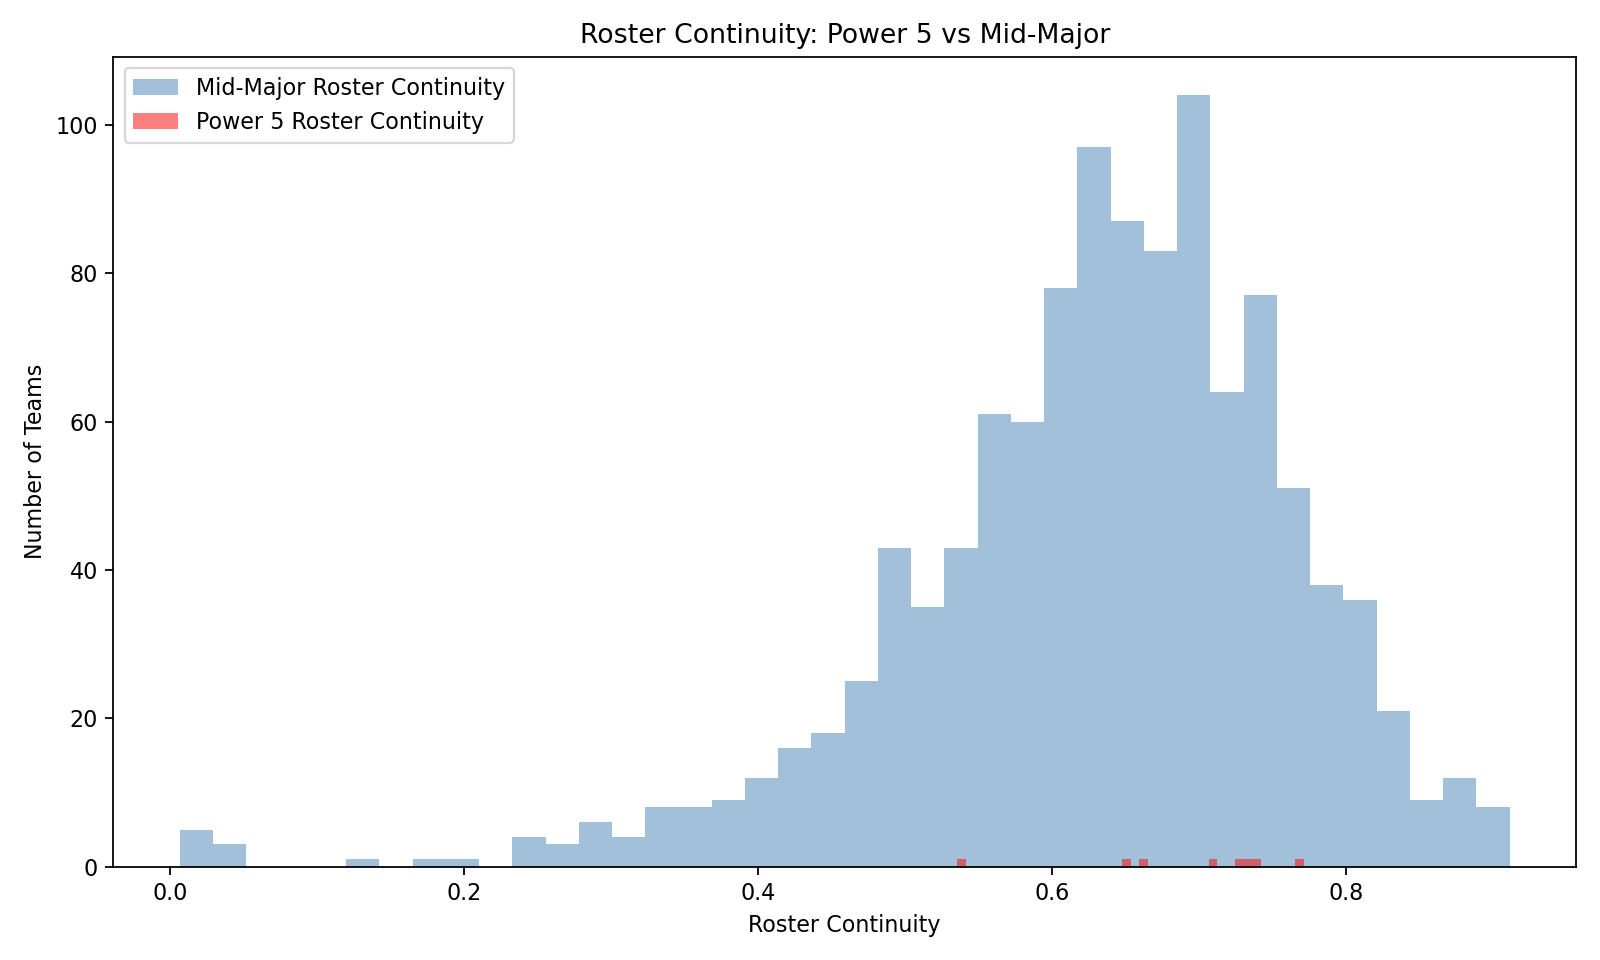

(array([  5.,   3.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   0.,   4.,
          3.,   6.,   4.,   8.,   8.,   9.,  12.,  16.,  18.,  25.,  43.,
         35.,  43.,  61.,  60.,  78.,  97.,  87.,  83., 104.,  64.,  77.,
         51.,  38.,  36.,  21.,   9.,  12.,   8.]),
 array([0.00647878, 0.02909088, 0.05170297, 0.07431507, 0.09692716,
        0.11953925, 0.14215135, 0.16476344, 0.18737554, 0.20998763,
        0.23259973, 0.25521182, 0.27782392, 0.30043601, 0.32304811,
        0.3456602 , 0.3682723 , 0.39088439, 0.41349648, 0.43610858,
        0.45872067, 0.48133277, 0.50394486, 0.52655696, 0.54916905,
        0.57178115, 0.59439324, 0.61700534, 0.63961743, 0.66222953,
        0.68484162, 0.70745371, 0.73006581, 0.7526779 , 0.77529   ,
        0.79790209, 0.82051419, 0.84312628, 0.86573838, 0.88835047,
        0.91096257]),
 <BarContainer object of 40 artists>)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
        1., 0., 0., 0., 0., 1.]),
 array([0.53538434, 0.54127568, 0.54716703, 0.55305837, 0.55894971,
        0.56484105, 0.57073239, 0.57662374, 0.58251508, 0.58840642,
        0.59429776, 0.60018911, 0.60608045, 0.61197179, 0.61786313,
        0.62375448, 0.62964582, 0.63553716, 0.6414285 , 0.64731984,
        0.65321119, 0.65910253, 0.66499387, 0.67088521, 0.67677656,
        0.6826679 , 0.68855924, 0.69445058, 0.70034192, 0.70623327,
        0.71212461, 0.71801595, 0.72390729, 0.72979864, 0.73568998,
        0.74158132, 0.74747266, 0.75336401, 0.75925535, 0.76514669,
        0.77103803]),
 <BarContainer object of 40 artists>)

Text(0.5, 1.0, 'Roster Continuity: Power 5 vs Mid-Major')

Text(0.5, 0, 'Roster Continuity')

Text(0, 0.5, 'Number of Teams')

In [15]:
#Specify which teams are part of the Power 5 conferences, the csv files we used for batting and pitching
#didn't have conference name, so I specified each team individually
Power5 = ('Boston College', 'California', 'Clemson', 'Duke', 'Florida State',
          'Georgia Tech', 'Louisville', 'Miami', 'NC State', 'North Carolina', 'Pittsburgh', 'SMU',
          'Stanford', 'Syracuse', 'Virginia', 'Virginia Tech', 'Wake Forest','Illinois',
          'Indiana', 'Iowa', 'Maryland', 'Michigan', 'Michigan State', 'Minnesota', 'Nebraska',
          'Northwestern', 'Ohio State', 'Oregon', 'Penn State', 'Purdue', 'Rutgers', 'UCLA', 'USC',
          'Washington', 'Wisconsin','Arizona', 'Arizona State', 'Baylor', 'BYU', 'Cincinnati', 'Colorado',
          'Houston', 'Iowa State', 'Kansas', 'Kansas State', 'Oklahoma State', 'TCU', 'Texas Tech', 'UCF',
          'Utah', 'West Virginia','Alabama', 'Arkansas', 'Auburn', 'Florida', 'Georgia', 'Kentucky', 'LSU',
          'Mississippi State', 'Missouri', 'Oklahoma', 'Ole Miss', 'South Carolina', 'Tennessee', 'Texas',
          'Texas A&M', 'Vanderbilt')
continuity['Power5']= continuity['team name'].isin(Power5).astype(int)
#2010 was the first year in our data so automatically had a 0 roster continuity. I removed 2010 so it wouldn't
#show as an outlier
continuity = continuity[continuity['roster_continuity'] > 0].copy()

#Create histogram of roster continuity with power 5 conferences highlighted in red
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = continuity[continuity['Power5'] == False]['roster_continuity']
power5 = continuity[continuity['Power5'] == True]['roster_continuity']


ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Roster Continuity')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Roster Continuity')

ax.set_title("Roster Continuity: Power 5 vs Mid-Major")
ax.set_xlabel("Roster Continuity")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("roster_continuity.pdf")
